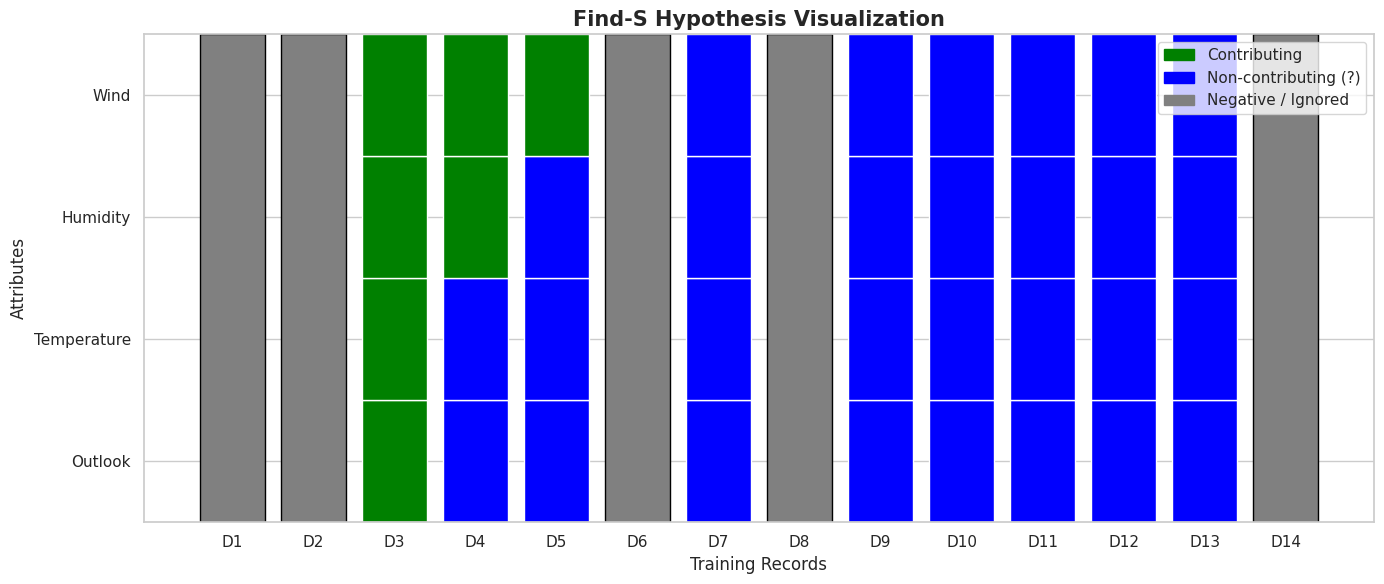

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Read data
data = pd.read_csv("/content/play_tennis.csv")
data.columns = data.columns.str.strip().str.lower()

attributes = ['outlook', 'temp', 'humidity', 'wind']

# Find-S
h = ['φ'] * 4
history = []

for i, row in data.iterrows():

    if row['play'] == 'Yes':

        for j, attr in enumerate(attributes):

            if h[j] == 'φ':
                h[j] = row[attr]

            elif h[j] != row[attr]:
                h[j] = '?'

        history.append(h.copy())

    else:
        history.append(None)


# Plot
plt.figure(figsize=(14, 6))

for i, h_now in enumerate(history):

    if h_now is None:
        # Negative → ignored
        plt.bar(i, 4, color='gray', edgecolor='black')

    else:
        # Positive → check each attribute
        for j, value in enumerate(h_now):

            color = 'green' if value not in ['?', 'φ'] else 'blue'

            plt.bar(
                i,
                1,
                bottom=j,
                color=color,
                edgecolor='white'
            )

# Labels
plt.xticks(range(len(data)), data['day'])
plt.yticks(
    [0.5, 1.5, 2.5, 3.5],
    ['Outlook', 'Temperature', 'Humidity', 'Wind']
)

plt.xlabel("Training Records")
plt.ylabel("Attributes")

plt.title(
    "Find-S Hypothesis Visualization",
    fontsize=15,
    fontweight='bold'
)

# Legend
plt.legend(handles=[
    Patch(color='green', label='Contributing'),
    Patch(color='blue', label='Non-contributing (?)'),
    Patch(color='gray', label='Negative / Ignored')
])

plt.ylim(0, 4)
plt.tight_layout()
plt.show()



DATASET
    day   outlook  temp humidity    wind play
0    D1     Sunny   Hot     High    Weak   No
1    D2     Sunny   Hot     High  Strong   No
2    D3  Overcast   Hot     High    Weak  Yes
3    D4      Rain  Mild     High    Weak  Yes
4    D5      Rain  Cool   Normal    Weak  Yes
5    D6      Rain  Cool   Normal  Strong   No
6    D7  Overcast  Cool   Normal  Strong  Yes
7    D8     Sunny  Mild     High    Weak   No
8    D9     Sunny  Cool   Normal    Weak  Yes
9   D10      Rain  Mild   Normal    Weak  Yes
10  D11     Sunny  Mild   Normal  Strong  Yes
11  D12  Overcast  Mild     High  Strong  Yes
12  D13  Overcast   Hot   Normal    Weak  Yes
13  D14      Rain  Mild     High  Strong   No

HYPOTHESIS AFTER EACH POSITIVE EXAMPLE
D3: <Overcast, Hot, High, Weak>
D4: <?, ?, High, Weak>
D5: <?, ?, ?, Weak>
D7: <?, ?, ?, ?>
D9: <?, ?, ?, ?>
D10: <?, ?, ?, ?>
D11: <?, ?, ?, ?>
D12: <?, ?, ?, ?>
D13: <?, ?, ?, ?>

FINAL HYPOTHESIS
<?, ?, ?, ?>


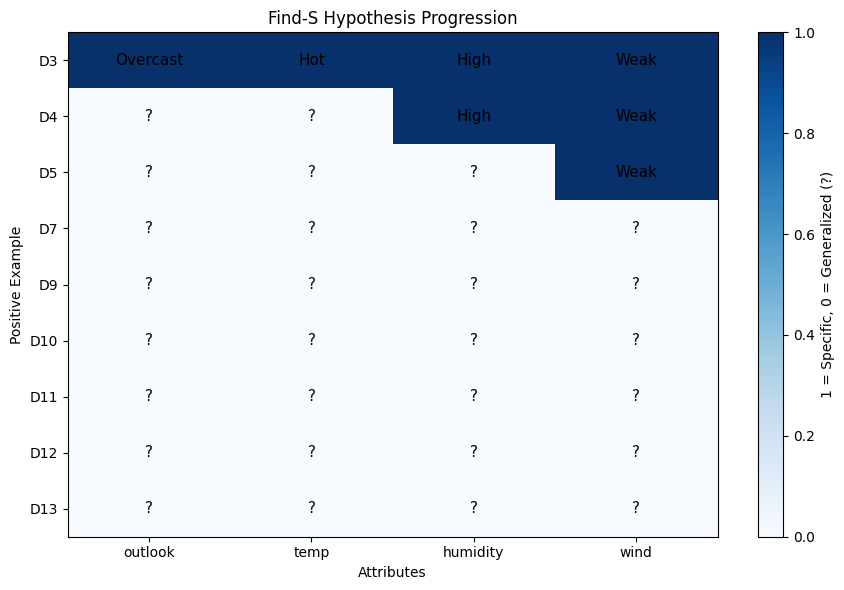

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# DATASET
# ============================================================

data = {
    "day": [
        "D1", "D2", "D3", "D4", "D5", "D6", "D7",
        "D8", "D9", "D10", "D11", "D12", "D13", "D14"
    ],
    "outlook": [
        "Sunny", "Sunny", "Overcast", "Rain", "Rain", "Rain",
        "Overcast", "Sunny", "Sunny", "Rain", "Sunny",
        "Overcast", "Overcast", "Rain"
    ],
    "temp": [
        "Hot", "Hot", "Hot", "Mild", "Cool", "Cool", "Cool",
        "Mild", "Cool", "Mild", "Mild", "Mild", "Hot", "Mild"
    ],
    "humidity": [
        "High", "High", "High", "High", "Normal", "Normal",
        "Normal", "High", "Normal", "Normal", "Normal",
        "High", "Normal", "High"
    ],
    "wind": [
        "Weak", "Strong", "Weak", "Weak", "Weak", "Strong",
        "Strong", "Weak", "Weak", "Weak", "Strong", "Strong",
        "Weak", "Strong"
    ],
    "play": [
        "No", "No", "Yes", "Yes", "Yes", "No", "Yes",
        "No", "Yes", "Yes", "Yes", "Yes", "Yes", "No"
    ]
}

df = pd.DataFrame(data)

# ============================================================
# PRINT DATASET
# ============================================================

print("\n" + "=" * 80)
print("DATASET")
print("=" * 80)
print(df.to_string(index=True))

# ============================================================
# FIND-S ALGORITHM
# ============================================================

attributes = ["outlook", "temp", "humidity", "wind"]

hypothesis = None
hypothesis_history = []

for index, row in df.iterrows():

    # Ignore negative examples
    if row["play"] == "Yes":

        current_example = [
            row["outlook"],
            row["temp"],
            row["humidity"],
            row["wind"]
        ]

        # First positive example
        if hypothesis is None:
            hypothesis = current_example.copy()

        # Compare with later positive examples
        else:
            for i in range(len(attributes)):
                if hypothesis[i] != current_example[i]:
                    hypothesis[i] = "?"

        # Store every hypothesis
        hypothesis_history.append(
            (row["day"], hypothesis.copy())
        )

# ============================================================
# PRINT HYPOTHESIS AFTER EACH POSITIVE EXAMPLE
# ============================================================

print("\n" + "=" * 80)
print("HYPOTHESIS AFTER EACH POSITIVE EXAMPLE")
print("=" * 80)

for day, h in hypothesis_history:
    print(
        f"{day}: "
        f"<{h[0]}, {h[1]}, {h[2]}, {h[3]}>"
    )

# ============================================================
# FINAL HYPOTHESIS
# ============================================================

print("\n" + "=" * 80)
print("FINAL HYPOTHESIS")
print("=" * 80)

print(
    f"<{hypothesis[0]}, "
    f"{hypothesis[1]}, "
    f"{hypothesis[2]}, "
    f"{hypothesis[3]}>"
)

# ============================================================
# VISUALIZE ALL HYPOTHESES
# ============================================================

# Convert hypotheses to numerical values:
# 1 = specific value
# 0 = generalized '?'

visual_data = []

for day, h in hypothesis_history:
    row_values = []

    for value in h:
        if value == "?":
            row_values.append(0)
        else:
            row_values.append(1)

    visual_data.append(row_values)

plt.figure(figsize=(9, 6))

plt.imshow(
    visual_data,
    cmap="Blues",
    aspect="auto"
)

plt.xticks(
    range(len(attributes)),
    attributes
)

plt.yticks(
    range(len(hypothesis_history)),
    [day for day, h in hypothesis_history]
)

plt.xlabel("Attributes")
plt.ylabel("Positive Example")
plt.title("Find-S Hypothesis Progression")

# Put actual hypothesis values inside the cells
for i, (day, h) in enumerate(hypothesis_history):
    for j, value in enumerate(h):
        plt.text(
            j,
            i,
            value,
            ha="center",
            va="center",
            fontsize=11,
            color="black"
        )

plt.colorbar(
    label="1 = Specific, 0 = Generalized (?)"
)

plt.tight_layout()
plt.show()


Step-by-step hypothesis:
  h0: {'outlook': '0', 'temp': '0', 'humidity': '0', 'wind': '0'}
  Ex1 (neg): {'outlook': '0', 'temp': '0', 'humidity': '0', 'wind': '0'}
  h2: {'outlook': 'Sunny', 'temp': 'Mild', 'humidity': 'Normal', 'wind': 'Strong'}
  h3: {'outlook': '?', 'temp': '?', 'humidity': 'Normal', 'wind': '?'}
  Ex4 (neg): {'outlook': '?', 'temp': '?', 'humidity': 'Normal', 'wind': '?'}
  h5: {'outlook': '?', 'temp': '?', 'humidity': 'Normal', 'wind': '?'}
  Ex6 (neg): {'outlook': '?', 'temp': '?', 'humidity': 'Normal', 'wind': '?'}
  h7: {'outlook': '?', 'temp': '?', 'humidity': 'Normal', 'wind': '?'}
  h8: {'outlook': '?', 'temp': '?', 'humidity': 'Normal', 'wind': '?'}
  Ex9 (neg): {'outlook': '?', 'temp': '?', 'humidity': 'Normal', 'wind': '?'}
  h10: {'outlook': '?', 'temp': '?', 'humidity': 'Normal', 'wind': '?'}
  Ex11 (neg): {'outlook': '?', 'temp': '?', 'humidity': 'Normal', 'wind': '?'}
  h12: {'outlook': '?', 'temp': '?', 'humidity': 'Normal', 'wind': '?'}
  h13: {'out

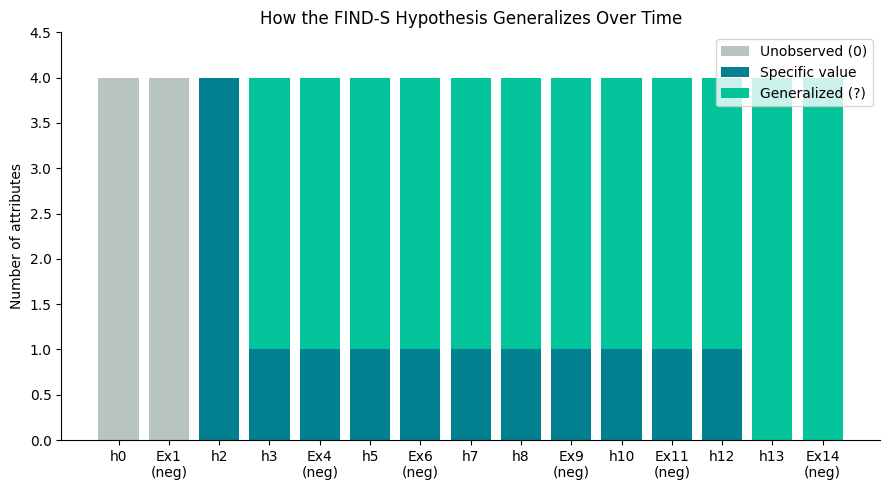

Saved: specificity_trend.png


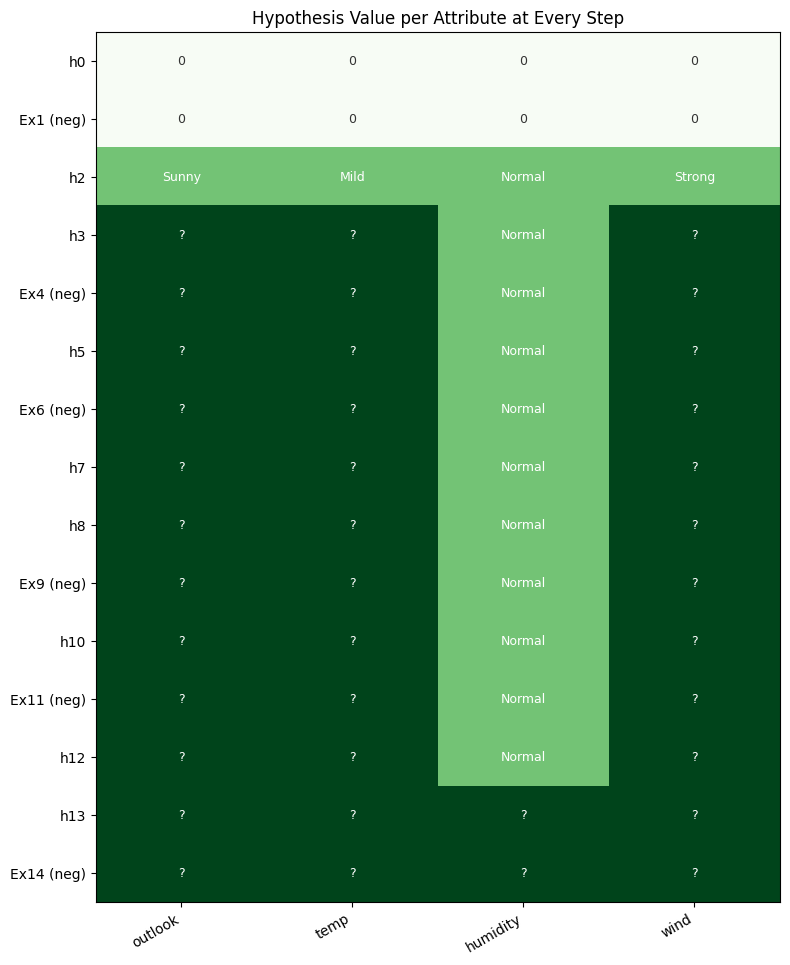

Saved: hypothesis_heatmap.png


In [ ]:
"""
FIND-S Algorithm with Visual Analysis
======================================
Runs FIND-S on the "Go Hiking" dataset, keeps a full history of the
hypothesis after every training example, then plots:

  1. Specificity trend  -> stacked bar chart: how many attributes are
     unobserved / specific / generalized ("?") at each step.
  2. Hypothesis heatmap -> attribute-by-step grid showing exactly which
     attribute changed and when.

Hypothesis notation used here:
    '0'  -> no value accepted yet (most specific / "not observed")
    '?'  -> any value accepted (fully general)
    'x'  -> a specific required value (e.g. "Sunny")
"""

import numpy as np
import matplotlib.pyplot as plt


# ----------------------------------------------------------------------
# 1. FIND-S core algorithm (returns full step-by-step history)
# ----------------------------------------------------------------------
def find_s_with_history(training_data, target_col="hike", positive_label="Yes"):
    attributes = [a for a in training_data[0].keys() if a != target_col]
    hypothesis = {attr: "0" for attr in attributes}

    # history entries: (label_for_x_axis, hypothesis_snapshot, was_positive)
    history = [("h0", dict(hypothesis), None)]

    for i, example in enumerate(training_data, start=1):
        label = example[target_col]

        if label != positive_label:
            history.append((f"Ex{i}\n(neg)", dict(hypothesis), False))
            continue

        for attr in attributes:
            if hypothesis[attr] == "0":
                hypothesis[attr] = example[attr]
            elif hypothesis[attr] != example[attr]:
                hypothesis[attr] = "?"

        history.append((f"h{i}", dict(hypothesis), True))

    return hypothesis, history, attributes


# ----------------------------------------------------------------------
# 2. Plot: specificity trend (stacked bar chart)
# ----------------------------------------------------------------------
def plot_specificity_trend(history, attributes, save_as="specificity_trend.png"):
    steps = [h[0] for h in history]
    unobserved, specific, general = [], [], []

    for _, hyp, _ in history:
        g = sum(1 for v in hyp.values() if v == "?")
        u = sum(1 for v in hyp.values() if v == "0")
        s = len(attributes) - g - u
        unobserved.append(u)
        specific.append(s)
        general.append(g)

    x = np.arange(len(steps))
    fig, ax = plt.subplots(figsize=(9, 5))

    ax.bar(x, unobserved, label="Unobserved (0)", color="#B7C4C2")
    ax.bar(x, specific, bottom=unobserved, label="Specific value", color="#028090")
    bottom2 = np.array(unobserved) + np.array(specific)
    ax.bar(x, general, bottom=bottom2, label="Generalized (?)", color="#02C39A")

    ax.set_xticks(x)
    ax.set_xticklabels(steps)
    ax.set_ylabel("Number of attributes")
    ax.set_title("How the FIND-S Hypothesis Generalizes Over Time")
    ax.set_ylim(0, len(attributes) + 0.5)
    ax.legend(loc="upper right")
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.savefig(save_as, dpi=150)
    plt.show()
    print(f"Saved: {save_as}")


# ----------------------------------------------------------------------
# 3. Plot: hypothesis evolution heatmap
# ----------------------------------------------------------------------
def plot_hypothesis_heatmap(history, attributes, save_as="hypothesis_heatmap.png"):
    # encode: 0 = unobserved, 1 = specific, 2 = general(?)
    grid = []
    for _, hyp, _ in history:
        row = [0 if hyp[a] == "0" else (2 if hyp[a] == "?" else 1) for a in attributes]
        grid.append(row)
    grid = np.array(grid)

    fig, ax = plt.subplots(figsize=(8, 0.55 * len(history) + 1.5))
    im = ax.imshow(grid, cmap="Greens", aspect="auto", vmin=0, vmax=2)

    ax.set_xticks(range(len(attributes)))
    ax.set_xticklabels(attributes, rotation=30, ha="right")
    ax.set_yticks(range(len(history)))
    ax.set_yticklabels([h[0].replace("\n", " ") for h in history])

    for i, (_, hyp, _) in enumerate(history):
        for j, attr in enumerate(attributes):
            color = "white" if grid[i, j] >= 1 else "#333333"
            ax.text(j, i, hyp[attr], ha="center", va="center", fontsize=9, color=color)

    ax.set_title("Hypothesis Value per Attribute at Every Step")
    plt.tight_layout()
    plt.savefig(save_as, dpi=150)
    plt.show()
    print(f"Saved: {save_as}")


# ----------------------------------------------------------------------
# 4. Run everything on the Go Hiking dataset
# ----------------------------------------------------------------------
if __name__ == "__main__":
    training_data = [
        {"outlook": "Sunny", "temp": "Hot", "humidity": "High", "wind": "Weak", "hike": "No"},
        {"outlook": "Sunny", "temp": "Mild", "humidity": "Normal", "wind": "Strong", "hike": "Yes"},
        {"outlook": "Overcast", "temp": "Cool", "humidity": "Normal", "wind": "Weak", "hike": "Yes"},
        {"outlook": "Rain", "temp": "Mild", "humidity": "High", "wind": "Weak", "hike": "No"},
        {"outlook": "Rain", "temp": "Cool", "humidity": "Normal", "wind": "Weak", "hike": "Yes"},
        {"outlook": "Rain", "temp": "Cool", "humidity": "Normal", "wind": "Strong", "hike": "No"},
        {"outlook": "Overcast", "temp": "Hot", "humidity": "Normal", "wind": "Strong", "hike": "Yes"},
        {"outlook": "Sunny", "temp": "Cool", "humidity": "Normal", "wind": "Weak", "hike": "Yes"},
        {"outlook": "Sunny", "temp": "Mild", "humidity": "High", "wind": "Strong", "hike": "No"},
        {"outlook": "Overcast", "temp": "Mild", "humidity": "Normal", "wind": "Weak", "hike": "Yes"},
        {"outlook": "Rain", "temp": "Hot", "humidity": "High", "wind": "Strong", "hike": "No"},
        {"outlook": "Sunny", "temp": "Mild", "humidity": "Normal", "wind": "Weak", "hike": "Yes"},
        {"outlook": "Overcast", "temp": "Hot", "humidity": "High", "wind": "Weak", "hike": "Yes"},
        {"outlook": "Rain", "temp": "Mild", "humidity": "Normal", "wind": "Strong", "hike": "No"},
    ]

    final_hypothesis, history, attributes = find_s_with_history(training_data)

    print("Step-by-step hypothesis:")
    for label, hyp, _ in history:
        print(f"  {label.replace(chr(10), ' ')}: {hyp}")
    print(f"\nFinal hypothesis: {final_hypothesis}")

    plot_specificity_trend(history, attributes)
    plot_hypothesis_heatmap(history, attributes)
